Maciek Gilecki 173142 Lab 4

In [59]:
import cv2
import time
import gymnasium as gym
from google.colab import output
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
mode = "rgb_array"
if mode == "None":
    mode = None


(21, 7, 1)


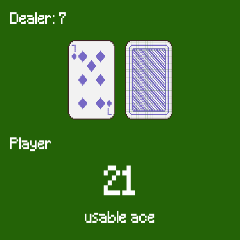

In [60]:
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
observation, _ = env.reset()

print(f"{observation}")
img = env.render()
w, h, _ = img.shape
ratio = int(h / w)
new_w, new_h = (ratio * 240), 240
cv2_imshow(cv2.resize(img, (new_w, new_h))) #OpenCV

In [61]:
env.action_space, env.observation_space # Przestrzeń akcji i obseracje

(Discrete(2), Tuple(Discrete(32), Discrete(11), Discrete(2)))

In [62]:
from os import truncate
# 0 - pass
# 1 - dobierz kartę
observation, reward, terminated, truncated, info = env.step(1)

In [63]:
observation, reward, terminated, truncated # Jeśli jeden z parametrów true to koniec gry

((15, 7, 0), 0.0, False, False)

In [64]:
env.close()

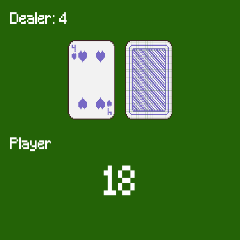

nagroda = 0.0, liczba punktów graczy = 18


In [65]:
def nowa_gra(env):
  observation, info = env.reset()
  img = env.render();
  w, h, _ = img.shape
  ratio = int(h / w)
  new_w, new_h = (ratio * 240), 240
  terminated = False
  truncated = False
  cv2_imshow(cv2.resize(img, (new_w, new_h)))
  time.sleep(0.1)

  if(observation[0] !=21):
    while (not terminated) and (not truncated):
      action = int(input('0 - pas, 1 - dobierz kartę\n'))
      observation, reward, terminated, truncated, info = env.step(action)
      output.clear(wait = True)
      time.sleep(0.1)

      img = env.render();
      cv2_imshow(cv2.resize(img, (new_w, new_h)))
      time.sleep(0.1)
  else:
    observation, reward, terminated, truncated, info = env.step(0)
  print(f"nagroda = {reward}, liczba punktów graczy = {observation[0]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=mode)
nowa_gra(env)
env.close()

Q-Learning
TO DO: sprawdz ile razy zwycięży skrypt przy losowaniu akcji

In [66]:
#Bez grafiki

def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    action = env.action_space.sample()
    print(f"{action}, obserwation, ", end='')
    observation, reward, terminated, truncated, info = env.step(action)
    print(f"{observation}, {reward}, {terminated}")
  print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")

env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)
nowa_gra_sample(env)
env.close()

0, obserwation, (13, 1, 0), -1.0, True
nagroda = -1.0, liczba punktów gracza = 13, liczba punktów przeciwnika = 1


Taxi

369


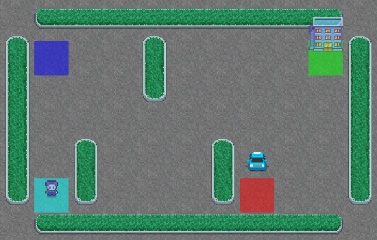

In [67]:
env = gym.make('Taxi-v4' , render_mode=mode) # rgb_array
#env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode='rgb_array') # rgb_array

#observation, info = env.reset()
observation, _ = env.reset()
print(f"{observation}")
img = env.render();
w, h, _ = img.shape
ratio = h/w                 # !!!
new_w, new_h = int(ratio* 240), 240 # !!!
cv2_imshow( cv2.resize(img, (new_w, new_h)) ) # OpenCV
#env.close()

In [68]:
env.action_space, env.observation_space

(Discrete(6), Discrete(500))

In [69]:
def flatten_state(env, obs):
    if isinstance(obs, int): # dla taxi
        return obs
    else: # dla blackjack
        ans = obs[0];
        prod = 1;
        for n in range(1, len(obs)):
            prod *= env.observation_space[n-1].n
            ans += prod*obs[n]
        return ans

def max_states(env, obs):
    prod = 1
    if isinstance(env.observation_space, gym.spaces.tuple.Tuple):
        for i in range(len(env.observation_space)):
            prod *= env.observation_space[i].n
    else:
        prod = env.observation_space.n
    return prod

# test
observation, _ = env.reset()
print(observation)
flatten_state(env, observation), max_states(env, observation)


211


(211, np.int64(500))

In [70]:
def nowa_gra_sample(env):
  observation, info = env.reset()
  terminated = False
  truncated = False
  while (not terminated) and (not truncated):
    # implementacja Q-learning --- do zrobienia
    action = env.action_space.sample() # losowo wybrana akcja # !!!!!!!!!!!!!!!!
    #print(f"{action}, {observation}, ", end='')
    observation, reward, terminated, truncated, info = env.step( action )
    #print(f"{observation}, {reward}, {terminated}")
  #print(f"nagroda = {reward}, liczba punktów gracza = {observation[0]}, liczba punktów przeciwnika = {observation[1]}")
  return reward
env = gym.make('Blackjack-v1', natural=True, sab=False, render_mode=None)

rewards = 0
draws = 0
for i in range(1000):
  tmp = round(nowa_gra_sample(env))
  if tmp > 0:
    rewards += 1
  elif tmp == 0:
    draws += 1
# rewards
print(f"{100*rewards / 1000.0}%, {rewards}, {draws}, {1000-(rewards+draws)}")


29.4%, 294, 36, 670


In [71]:
env.observation_space, 32*11*2, env.action_space.n

(Tuple(Discrete(32), Discrete(11), Discrete(2)), 704, np.int64(2))

In [78]:
def q_learning(env, Q_table, episodes=1000, alpha=0.5, gamma=0.9, epsilon=0.8):
    rewards = []
    steps = []
    for episode in range(episodes):
        step = 0  # reset per episode
        episode_reward = 0
        observation, info = env.reset()
        terminated = False
        truncated = False
        while (not terminated) and (not truncated):
            state = flatten_state(env, observation)
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q_table[state, :])

            observation, reward, terminated, truncated, info = env.step(action)
            next_state = flatten_state(env, observation)
            episode_reward += reward

            Q_table[state, action] = (1 - alpha) * Q_table[state, action] + alpha * (reward + gamma * np.max(Q_table[next_state, :]))

            step += 1
            state = next_state

        rewards.append(episode_reward)
        steps.append(step)
        epsilon -= epsilon / episodes

        print(f"\r{100*episode//(episodes-1):>3}%|", end="")
        for j in range(10):
            if 10*episode//(episodes-1) % 11 > j:
                print("#", end="")
            else:
                print(" ", end="")
        print(f"| {episode:3}, {epsilon:.3f}, {episode_reward:5}, {step:5}", end="")

    return Q_table, rewards, steps

In [73]:
env = gym.make("Taxi-v4", render_mode=None)
observation, info = env.reset()
prod = max_states(env, observation)
Q_table = np.zeros([prod, env.action_space.n])
Q_table, rewards, steps = q_learning(env, Q_table, episodes=2000, alpha=0.1, gamma=0.6, epsilon=0.1)
env.close()


100%|##########| 1999, 0.037,     7,    14

In [74]:
print(*Q_table)

[0. 0. 0. 0. 0. 0.] [-2.29768015 -2.29130233 -2.29884562 -2.30702325 -2.27366919 -4.42178034] [-1.79234835 -1.70474241 -1.80470202 -1.69234879 -0.7504171  -3.60030813] [-2.17416575 -2.14708191 -2.20333201 -2.15959335 -2.12215634 -4.46518019] [-2.4712369  -2.47192545 -2.47206071 -2.47174881 -5.70775893 -5.77775657] [0. 0. 0. 0. 0. 0.] [-2.47374648 -2.47384225 -2.47423141 -2.47411158 -4.498264   -4.92789139] [-2.44320907 -2.44314477 -2.44299278 -2.44127384 -5.03383062 -8.31201238] [-2.29158669 -2.29072966 -2.29425878 -2.29898429 -5.66179433 -2.76284352] [-2.46272824 -2.46233658 -2.46235407 -2.46258838 -5.79957233 -6.88876824] [0. 0. 0. 0. 0. 0.] [-2.43354944 -2.43275479 -2.43226722 -2.43301081 -3.67058301 -7.17884824] [-2.4691825  -2.46816655 -2.46820422 -2.46825203 -6.74420495 -4.42890391] [-2.40930022 -2.40832784 -2.40816078 -2.40813168 -4.44133251 -5.70255694] [-2.46485652 -2.46505397 -2.4658118  -2.46545024 -3.68247206 -7.21516865] [0. 0. 0. 0. 0. 0.] [ 2.14040595  5.67352623  0.0814

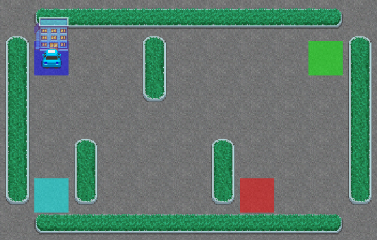

11


In [75]:
def nowa_gra_q_table(env):
    episode_reward = 0
    observation, info = env.reset()
    terminated = False
    truncated = False

    # render pierwszej klatki
    img = env.render()
    w, h, _ = img.shape
    ratio = h / w
    new_w, new_h = int(ratio * 240), 240
    cv2_imshow(cv2.resize(img, (new_w, new_h)))

    while (not terminated) and (not truncated):
        state = flatten_state(env, observation)
        action = np.argmax(Q_table[state, :])
        observation, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        output.clear(wait=True)
        img = env.render()
        cv2_imshow(cv2.resize(img, (new_w, new_h)))
        time.sleep(0.5)
    return episode_reward

env2 = gym.make("Taxi-v4", render_mode=mode)
print(nowa_gra_q_table(env2))


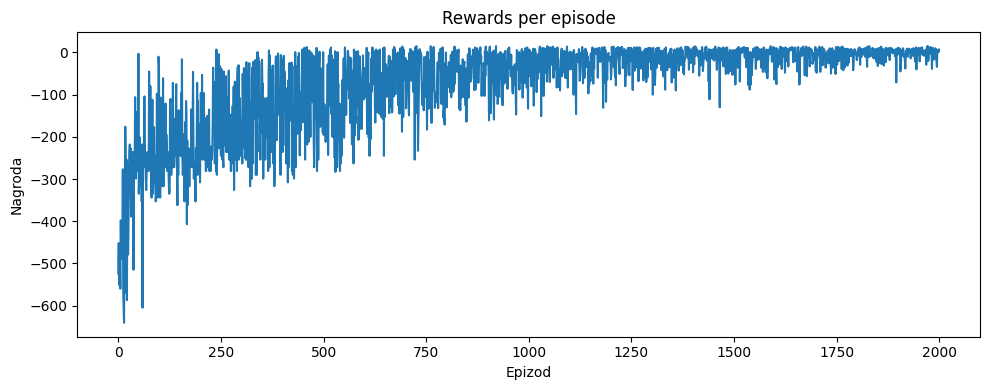

In [76]:
# Wykres 1: nagrody w kolejnych epizodach
plt.figure(figsize=(10, 4))
plt.plot(rewards)
plt.title("Rewards per episode")
plt.xlabel("Epizod")
plt.ylabel("Nagroda")
plt.tight_layout()
plt.show()


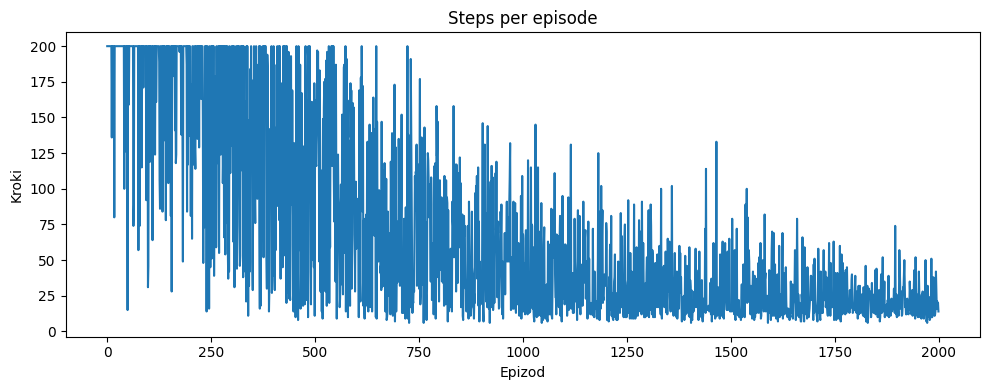

In [77]:
# Wykres 2: liczba kroków w kolejnych epizodach
plt.figure(figsize=(10, 4))
plt.plot(steps)
plt.title("Steps per episode")
plt.xlabel("Epizod")
plt.ylabel("Kroki")
plt.tight_layout()
plt.show()


## Podsumowanie / Wnioski

W ramach laboratorium zaimplementowano algorytm Q-learning dla środowisk Blackjack oraz Taxi z biblioteki Gymnasium.

**Blackjack:** Losowa polityka wygrywa ok. 40% partii. Algorytm Q-learning stopniowo optymalizuje Q-table, jednak środowisko jest trudne — duży wpływ losowości (tasowanie kart) ogranicza przewagę wyuczonej strategii.

**Taxi:** Środowisko deterministyczne, co sprzyja nauce. Po 2000 epizodach agent poprawnie odbiera i dostarcza pasażera, a wykres rewards(episode) wyraźnie rośnie ku wartości ~8, zaś steps(episode) maleje — agent uczy się krótszych tras. Zmniejszanie epsilon w trakcie treningu (eksploracja → eksploatacja) widocznie przyspiesza zbieżność.

**Wnioski:** Q-learning sprawdza się dobrze w dyskretnych, niezbyt dużych przestrzeniach stanów. Dla środowisk ciągłych (np. CarRacing) wymagałby dyskretyzacji lub zastąpienia przez Deep Q-Network (DQN).
